# Tutorial 2: Find a lumped LC for a distributed element

In [ ]:
from models import *

## 1a. LOM Fit

### Give the program the geometry of your CPW element

In [ ]:
fitter = LOMFitter(freq=rf.Frequency(1e9, 10e9, 100_001, unit='Hz'), d=0.007, Cc1=5e-14, Cc2=5e-14, Ctog1=5e-14, Ctog2=5e-14, verbose=True)

### Extract Leff, Ceff using the fitter

In [3]:
Leff, Ceff = fitter.fit_leff_ceff()

Frequency (GHz): 7.41871  Linewidth (MHz): 57.87
Frequency (Data) (GHz): 7.41850873696  Linewidth (Data) (MHz): 56.64150288000011
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.2219e+00                                    1.11e+05    
       1              2         2.2928e-01      8.99e+00       5.37e-14       8.88e+01    
       2              3         3.1748e-02      1.98e-01       9.56e-13       5.33e+03    
       3              4         1.1597e-02      2.02e-02       1.95e-15       1.60e-01    
       4              5         1.1597e-02      3.16e-07       1.83e-15       1.67e-01    
       5              6         1.1597e-02      1.10e-10       2.01e-19       2.51e-05    
       6             13         1.1597e-02      0.00e+00       0.00e+00       2.51e-05    
`xtol` termination condition is satisfied.
Function evaluations 13, initial cost 9.2219e+00, final cost 1.1597e-02, first-order optimality 2.5

### Find the error in the model in frequency and linewidth

In [4]:
err_f0, err_k = fitter.f0_kappa_error()
print(err_f0, err_k)

6.230901874643777e-05 0.017137680863671734


### Add your loads (up to two) and compare shifted frequencies

In [5]:

shifts = fitter.frequency_shift({"Lload1": 5e-10, "Cload1": 5e-13, "Lload2": 1e-10, "Cload2": 5e-13})
print(shifts)

{'f0_cpw_bare_hz': 7418508736.96, 'f0_lom_bare_hz': 7418513359.36, 'cpw_shifted_frequencies_hz': array([7.38345874]), 'lom_shifted_frequencies_hz': array([7.38346374]), 'cpw_shift_hz': 7418508729.576541, 'lom_shift_hz': 7418513351.976536, 'cpw_f1_hz': 7.38345873696, 'lom_f1_hz': 7.3834637369600005}


### Summarize the new circuit and plot it

In [6]:
out = fitter.summary()
print(out)

{'CPW length': 0.007, 'Cc1': 5e-14, 'Cc2': 5e-14, 'Ctog': 5e-14, 'Cclaw': 5e-14, 'LC C': 6.567724090796465e-13, 'LC L': 6.081926997466065e-10, 'CPW Frequency (GHz)': 7418508736.96, 'LC Frequency (GHz)': 7418513359.36, 'Frequency Error (%)': 6.230901874643777e-05, 'CPW Kappa (MHz)': 56641502880.000114, 'LC Kappa (MHz)': 56651209920.00008, 'Linewidth Error (%)': 0.017137680863671734, 'Cost': 0.011596878664723665}


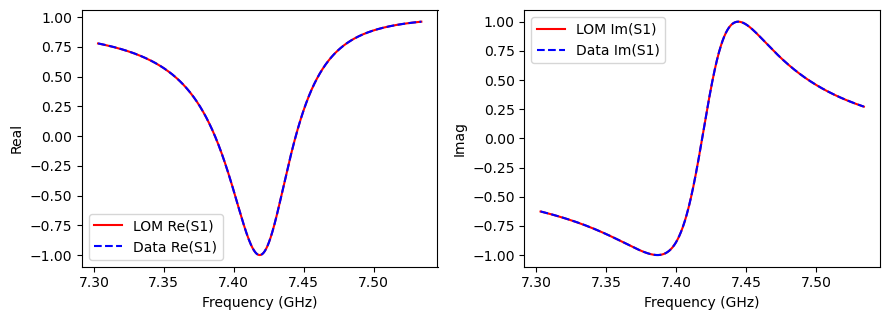

In [7]:
fitter.plot()

## 1b. Foster Fit

In [1]:
from core.models import *

In [4]:
freq = rf.Frequency(1, 20, 100_001, "GHz")
cpw = CPW(freq, w = 11.7e-6,   
                s = 5.1e-6, #spacing = 5.1um
                t=0, #thickness = 200nm
                h=500e-6, #substrate height = 525um
                rho=1e-19, #closest to 0 this thing goes
                ep_r = 11.45, #ultracold silicon
                has_metal_backside=True,
                tand=0,)
line = cpw.line(d=0.007, unit='m', name='cpw line')
port=rf.Circuit.Port(freq, name="P1", z0=500)
port2=rf.Circuit.Port(freq, name="P2", z0=500)
cnx2 = [[(port, 0), (line, 0)],
        [(line, 1), (port2, 0)]]

ckt = rf.Circuit(cnx2, name="Port_Resonator")

ntw = ckt.network

In [5]:
fs = FosterSynthesis(YL=1/500, port=1, fit_half_window=5)

In [7]:
f0, Ceff, Leff = fs.synthesize_first_mode_from_s22(ntw, m=2, n=2, prefer_minimum=True)
print("f0 =", f0, "Hz")
print("Ceff =", Ceff, "F")
print("Leff =", Leff, "H")

f0 = 8582330000.0 Hz
Ceff = 6.221266155192232e-13 F
Leff = 5.52778397502574e-10 H


# 1c. Approximate Fit